# Đánh giá và tối ưu gợi ý Product Detail

Notebook này trình bày quy trình thực nghiệm theo dạng một bài toán máy học: **dữ liệu → validation → hyperparameter tuning → chọn mô hình → final evaluation → so sánh baseline**.

Notebook này chỉ đánh giá ngữ cảnh **Product Detail / Similar Products**: công thức hiện tại của đề tài và cosine truyền thống. Home và Cart có notebook riêng vì khác mục tiêu liên quan, dữ liệu, tập ứng viên và baseline.

> **Cập nhật 17/08/2026:** phần diễn giải và kết luận đã được rà soát theo output hiện tại của notebook. Tập final chỉ dùng để báo cáo; việc chọn trọng số Product Detail sử dụng 646 trường hợp validation và không nhìn vào 100 trường hợp final.

## 1. Công thức tham khảo và công thức đề xuất

### Cosine similarity — công thức tham khảo

$$\operatorname{cosine}(x,y)=\frac{x\cdot y}{\lVert x\rVert\lVert y\rVert}$$

Cosine được sử dụng trong Vector Space Model của Salton, Wong và Yang (1975). Trong thí nghiệm này, vector nhị phân được tạo từ category/role, gender, brand, color và price bucket.

### Weighted attribute — công thức do đề tài xây dựng

$$S_{attribute}=0.35C_{category}+0.15C_{gender}+0.10C_{brand}+0.15C_{color}+0.15C_{price}$$

### Product Detail hybrid — tham số cần tối ưu

$$S_{similar}=\alpha S_{attribute}+\beta S_{cosine}+\gamma S_{popularity},\quad \alpha+\beta+\gamma=1$$

Các hệ số không lấy từ bài báo mà được chọn bằng grid search trên validation.

**Tài liệu tham khảo:**

- Salton, Wong & Yang (1975), *A Vector Space Model for Automatic Indexing*, DOI: 10.1145/361219.361220.
- Pazzani & Billsus (2007), *Content-Based Recommendation Systems*, DOI: 10.1007/978-3-540-72079-9_10.
- Burke (2002), *Hybrid Recommender Systems: Survey and Experiments*, DOI: 10.1023/A:1021240730564.

In [1]:
from pathlib import Path
from collections import Counter
from html import escape
from IPython.display import HTML, SVG, display
import json
import math
import time

def find_repo_root():
    for start in (Path.cwd(), Path.cwd().resolve()):
        for candidate in (start, *start.parents):
            if (candidate / 'backend').is_dir() and (candidate / 'evaluation' / 'recommendation').is_dir():
                return candidate
    raise FileNotFoundError('Không tìm thấy repository root')

ROOT = find_repo_root()
EVAL = ROOT / 'evaluation' / 'recommendation'
VALIDATION_PATH = EVAL / 'data' / 'processed' / 'amazon-fashion-similar-validation-1000.json'
FINAL_PATH = EVAL / 'data' / 'processed' / 'amazon-fashion-final-test.json'
def load_json(path):
    if not path.exists():
        raise FileNotFoundError(f'Thiếu dữ liệu: {path}')
    return json.loads(path.read_text(encoding='utf-8'))

def show_table(rows, columns=None, digits=6):
    if not rows:
        return display(HTML('<em>Không có dữ liệu</em>'))
    columns = columns or list(rows[0])
    def fmt(value):
        if isinstance(value, float):
            return f'{value:.{digits}f}'
        return str(value)
    head = ''.join(f'<th style="padding:6px;text-align:left">{escape(str(c))}</th>' for c in columns)
    body = ''.join('<tr>' + ''.join(
        f'<td style="padding:6px;border-top:1px solid #ddd">{escape(fmt(row.get(c, "")))}</td>'
        for c in columns) + '</tr>' for row in rows)
    return display(HTML(f'<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>'))

def line_chart(rows, x_key, y_key, title, x_label, y_label, selected_x=None):
    width,height,left,right,top,bottom=760,330,70,25,45,55
    xs=[r[x_key] for r in rows];ys=[r[y_key] for r in rows];xmin,xmax=min(xs),max(xs);ymax=max(ys)*1.08 or 1
    sx=lambda x:left+(x-xmin)/(xmax-xmin)*(width-left-right);sy=lambda y:height-bottom-y/ymax*(height-top-bottom)
    points=' '.join(f'{sx(r[x_key]):.1f},{sy(r[y_key]):.1f}' for r in rows);best=next((r for r in rows if selected_x is not None and abs(r[x_key]-selected_x)<1e-12),max(rows,key=lambda r:r[y_key]))
    p=[f'<svg width="100%" viewBox="0 0 {width} {height}" role="img" style="background:#fff;color:#111"><title>{escape(title)}</title><rect width="100%" height="100%" fill="#fff"/>',f'<text x="{width/2}" y="22" text-anchor="middle" fill="#111" font-size="16">{escape(title)}</text>',f'<line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#111" opacity=".5"/>',f'<line x1="{left}" y1="{height-bottom}" x2="{width-right}" y2="{height-bottom}" stroke="#111" opacity=".5"/>']
    for i in range(5):
        y=ymax*i/4;py=sy(y);x=xmin+(xmax-xmin)*i/4;px=sx(x);p += [f'<line x1="{left}" y1="{py:.1f}" x2="{width-right}" y2="{py:.1f}" stroke="#111" opacity=".12"/>',f'<text x="{left-8}" y="{py+4:.1f}" text-anchor="end" fill="#111" font-size="11">{y:.3f}</text>',f'<text x="{px:.1f}" y="{height-bottom+20}" text-anchor="middle" fill="#111" font-size="11">{x:.3f}</text>']
    p += [f'<polyline points="{points}" fill="none" stroke="#2563eb" stroke-width="2"/>',f'<circle cx="{sx(best[x_key]):.1f}" cy="{sy(best[y_key]):.1f}" r="5" fill="#dc2626"/>',f'<text x="{sx(best[x_key])-8:.1f}" y="{sy(best[y_key])-10:.1f}" text-anchor="end" fill="#111" font-size="11">best {best[x_key]:.3f} / {best[y_key]:.4f}</text>',f'<text x="{width/2}" y="{height-8}" text-anchor="middle" fill="#111" font-size="12">{escape(x_label)}</text>',f'<text transform="translate(15 {height/2}) rotate(-90)" text-anchor="middle" fill="#111" font-size="12">{escape(y_label)}</text>','</svg>'];display(SVG(''.join(p)))

def bar_chart(rows,label_key,value_key,title):
    width,label_w,row_h=760,250,34;height=48+row_h*len(rows);maximum=max(r[value_key] for r in rows) or 1
    p=[f'<svg width="100%" viewBox="0 0 {width} {height}" role="img" style="background:#fff;color:#111"><title>{escape(title)}</title><rect width="100%" height="100%" fill="#fff"/>',f'<text x="{width/2}" y="20" text-anchor="middle" fill="#111" font-size="16">{escape(title)}</text>']
    for i,r in enumerate(rows):
        y=35+i*row_h;bw=(width-label_w-75)*r[value_key]/maximum;p += [f'<text x="{label_w-8}" y="{y+17}" text-anchor="end" fill="#111" font-size="11">{escape(str(r[label_key]))}</text>',f'<rect x="{label_w}" y="{y}" width="{bw:.1f}" height="22" fill="#2563eb"/>',f'<text x="{label_w+bw+6:.1f}" y="{y+16}" fill="#111" font-size="11">{r[value_key]:.4f}</text>']
    p.append('</svg>');display(SVG(''.join(p)))

validation_dataset = load_json(VALIDATION_PATH)
final_dataset = load_json(FINAL_PATH)
validation_cases = [c for c in validation_dataset['cases'] if c['context'] == 'product_detail_similar']
final_similar_cases = [c for c in final_dataset['cases'] if c['context'] == 'product_detail_similar']

print('Repository:', ROOT)
print('Validation Product Detail cases:', len(validation_cases))
print('Final Product Detail cases:', len(final_similar_cases))

Repository: D:\LV\fashionshop\fashion-ecommerce-system
Validation Product Detail cases: 646
Final Product Detail cases: 100


## 2. Kiểm tra dữ liệu

Mỗi trường hợp có một sản phẩm nguồn, một sản phẩm relevant bị giữ lại và 200 ứng viên. Các tín hiệu phải được chuẩn hóa về $[0,1]$.

In [2]:
def audit_cases(cases, split_name):
    required = ('contentSimilarity', 'cosineSimilarity', 'popularity', 'business')
    invalid_signals = 0
    missing_relevant = 0
    duplicate_candidates = 0
    candidate_counts = []
    for case in cases:
        ids = [item['productId'] for item in case['candidates']]
        candidate_counts.append(len(ids))
        duplicate_candidates += int(len(ids) != len(set(ids)))
        missing_relevant += int(not set(case['relevantProductIds']).intersection(ids))
        for item in case['candidates']:
            for signal in required:
                value = item['signals'].get(signal)
                invalid_signals += int(not isinstance(value, (int, float)) or not 0 <= value <= 1)
    return {
        'split': split_name,
        'cases': len(cases),
        'min_candidates': min(candidate_counts),
        'max_candidates': max(candidate_counts),
        'missing_relevant': missing_relevant,
        'duplicate_cases': duplicate_candidates,
        'invalid_signals': invalid_signals,
    }

audit_rows = [
    audit_cases(validation_cases, 'validation'),
    audit_cases(final_similar_cases, 'final'),
]
show_table(audit_rows)
assert all(row['missing_relevant'] == row['duplicate_cases'] == row['invalid_signals'] == 0 for row in audit_rows)

split,cases,min_candidates,max_candidates,missing_relevant,duplicate_cases,invalid_signals
validation,646,200,200,0,0,0
final,100,200,200,0,0,0


## 3. Hàm xếp hạng và các metric

Các hàm dưới đây tái lập benchmark TypeScript: HR@K, Precision@K, Recall@K, MAP@K, MRR@K, NDCG@K, coverage và diversity reranking.

In [3]:
CATEGORY_PENALTY = 0.08
BRAND_PENALTY = 0.04

COSINE_WEIGHTS = {'content': 0.0, 'cosine': 1.0, 'popularity': 0.0, 'business': 0.0}

def candidate_score(candidate, weights):
    s = candidate['signals']
    return (weights['content'] * s['contentSimilarity']
            + weights['cosine'] * s['cosineSimilarity']
            + weights['popularity'] * s['popularity']
            + weights['business'] * s['business'])

def rank_case(case, weights, k):
    remaining = sorted(
        [(candidate_score(c, weights), c) for c in case['candidates']],
        key=lambda pair: (-pair[0], pair[1]['productId'])
    )
    selected = []
    category_counts, brand_counts = Counter(), Counter()
    while remaining and len(selected) < k:
        best_index, best_adjusted = 0, -math.inf
        for index, (score, candidate) in enumerate(remaining):
            category = candidate.get('categoryId') or f"unknown:{candidate['productId']}"
            brand = candidate.get('brandId') or f"unknown:{candidate['productId']}"
            adjusted = score - CATEGORY_PENALTY * category_counts[category] - BRAND_PENALTY * brand_counts[brand]
            if adjusted > best_adjusted:
                best_index, best_adjusted = index, adjusted
        score, candidate = remaining.pop(best_index)
        selected.append(candidate)
        category_counts[candidate.get('categoryId') or f"unknown:{candidate['productId']}"] += 1
        brand_counts[candidate.get('brandId') or f"unknown:{candidate['productId']}"] += 1
    return selected

def evaluate(cases, weights, k=5):
    hits = precision = recall = map_sum = mrr = ndcg = category_div = brand_div = 0.0
    recommended, catalog = set(), set()
    for case in cases:
        relevant = set(case['relevantProductIds'])
        catalog.update(c['productId'] for c in case['candidates'])
        ranked = rank_case(case, weights, k)
        hit_count = first_rank = 0
        average_precision = dcg = 0.0
        for index, candidate in enumerate(ranked, start=1):
            recommended.add(candidate['productId'])
            if candidate['productId'] not in relevant:
                continue
            hit_count += 1
            average_precision += hit_count / index
            dcg += 1 / math.log2(index + 1)
            first_rank = first_rank or index
        ideal_count = min(len(relevant), k)
        ideal_dcg = sum(1 / math.log2(index + 2) for index in range(ideal_count))
        hits += int(hit_count > 0)
        precision += hit_count / k
        recall += hit_count / len(relevant)
        map_sum += average_precision / ideal_count if ideal_count else 0
        mrr += 1 / first_rank if first_rank else 0
        ndcg += dcg / ideal_dcg if ideal_dcg else 0
        category_div += len({c.get('categoryId') for c in ranked if c.get('categoryId')}) / len(ranked)
        brand_div += len({c.get('brandId') for c in ranked if c.get('brandId')}) / len(ranked)
    n = len(cases)
    return {
        'cases': n, 'HR': hits / n, 'Precision': precision / n, 'Recall': recall / n,
        'MAP': map_sum / n, 'MRR': mrr / n, 'NDCG': ndcg / n,
        'Coverage': len(recommended) / len(catalog),
        'CategoryDiversity': category_div / n, 'BrandDiversity': brand_div / n,
    }

baseline_validation = evaluate(validation_cases, COSINE_WEIGHTS, k=5)
show_table([{'method': 'Cosine baseline', **baseline_validation}])

method,cases,HR,Precision,Recall,MAP,MRR,NDCG,Coverage,CategoryDiversity,BrandDiversity
Cosine baseline,646,0.092879,0.018576,0.092879,0.047162,0.047162,0.058253,0.286403,0.457276,0.873994


## 4. Hyperparameter tuning

Quá trình tương tự Optuna/GridSearch nhưng được triển khai minh bạch, không cần thư viện ngoài:

- **Coarse search:** toàn bộ simplex content/cosine/popularity, bước 0.05 — 231 cấu hình.
- **Fine search:** content $[0,0.20]$, popularity $[0,0.05]$, bước 0.005 — 451 cấu hình.
- Coarse và fine trùng 10 điểm biên; sau khử trùng lặp còn **672 cấu hình duy nhất**.
- Objective: NDCG@5; tie-break lần lượt HR, MAP, MRR, Recall, Precision, Coverage.
- Business bằng 0 vì Amazon không có tín hiệu sale/new-arrival tương đương production.

stage,step,generated,overlap_removed,evaluated
Coarse,0.05,231,0,included
Fine,0.005,451,10,included
Combined unique,mixed,682,10,672


Đã đánh giá 672 cấu hình duy nhất trong 149.4 giây
Best weights: {'content': 0.125, 'cosine': 0.875, 'popularity': 0.0, 'business': 0.0}


index,content,cosine,popularity,HR,NDCG,MAP,Coverage
501,0.125000,0.875000,0.000000,0.094427,0.059908,0.048839,0.287475
457,0.105000,0.895000,0.000000,0.094427,0.059908,0.048839,0.287118
468,0.110000,0.890000,0.000000,0.094427,0.059908,0.048839,0.287118
479,0.115000,0.885000,0.000000,0.094427,0.059908,0.048839,0.287118
490,0.120000,0.880000,0.000000,0.094427,0.059908,0.048839,0.287118
42,0.100000,0.900000,0.000000,0.094427,0.059908,0.048839,0.286939
382,0.070000,0.930000,0.000000,0.094427,0.059908,0.048839,0.286939
393,0.075000,0.925000,0.000000,0.094427,0.059908,0.048839,0.286939
426,0.090000,0.910000,0.000000,0.094427,0.059908,0.048839,0.286939
437,0.095000,0.905000,0.000000,0.094427,0.059908,0.048839,0.286939


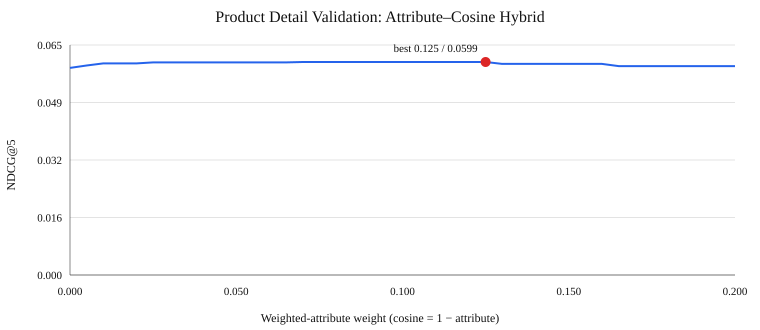

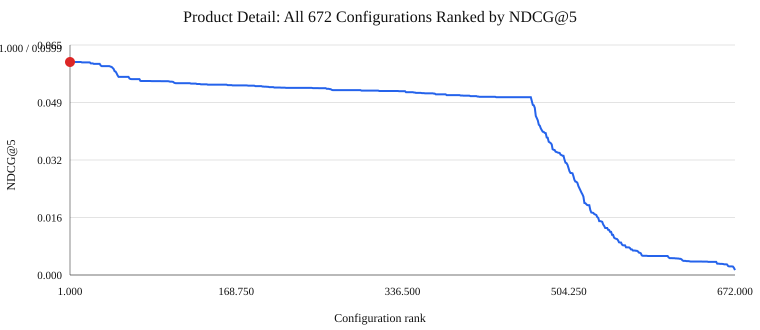

In [4]:
def float_range(start, end, step):
    count = round((end - start) / step)
    return [round(start + index * step, 3) for index in range(count + 1)]

def make_weights(content, popularity):
    return {
        'content': round(content, 3),
        'cosine': round(1 - content - popularity, 3),
        'popularity': round(popularity, 3),
        'business': 0.0,
    }

coarse_candidates = [
    make_weights(content, popularity)
    for content in float_range(0, 1, 0.05)
    for popularity in float_range(0, 1 - content, 0.05)
]
fine_candidates = [
    make_weights(content, popularity)
    for content in float_range(0, 0.20, 0.005)
    for popularity in float_range(0, 0.05, 0.005)
]
all_candidates = coarse_candidates + fine_candidates
grid = list({tuple(w[key] for key in ('content','cosine','popularity','business')): w for w in all_candidates}.values())
assert len(coarse_candidates) == 231 and len(fine_candidates) == 451 and len(all_candidates) == 682 and len(grid) == 672

def objective(metrics):
    return tuple(metrics[key] for key in ('NDCG', 'HR', 'MAP', 'MRR', 'Recall', 'Precision', 'Coverage'))

started = time.perf_counter()
search_results = []
for index, weights in enumerate(grid, start=1):
    metrics = evaluate(validation_cases, weights, k=5)
    search_results.append({'index': index, **weights, **metrics})
best = max(search_results, key=objective)
elapsed = time.perf_counter() - started
BEST_WEIGHTS = {key: best[key] for key in ('content', 'cosine', 'popularity', 'business')}

unique_search={tuple(r[key] for key in ('content','cosine','popularity','business')) for r in search_results}
search_audit=[
    {'stage':'Coarse','step':'0.05','generated':231,'overlap_removed':0,'evaluated':'included'},
    {'stage':'Fine','step':'0.005','generated':451,'overlap_removed':10,'evaluated':'included'},
    {'stage':'Combined unique','step':'mixed','generated':682,'overlap_removed':10,'evaluated':len(search_results)},
]
show_table(search_audit,['stage','step','generated','overlap_removed','evaluated'])
assert len(search_results)==len(unique_search)==672
print(f'Đã đánh giá {len(search_results)} cấu hình duy nhất trong {elapsed:.1f} giây')
print('Best weights:', BEST_WEIGHTS)
show_table(sorted(search_results, key=objective, reverse=True)[:10],
           ['index', 'content', 'cosine', 'popularity', 'HR', 'NDCG', 'MAP', 'Coverage'])
content_curve = sorted({r['content']: r for r in search_results if r['popularity'] == 0 and r['content'] <= 0.20}.values(), key=lambda r:r['content'])
line_chart(content_curve,'content','NDCG','Product Detail Validation: Attribute–Cosine Hybrid','Weighted-attribute weight (cosine = 1 − attribute)','NDCG@5',BEST_WEIGHTS['content'])
ranked_search=[{'rank':i,'NDCG':r['NDCG']} for i,r in enumerate(sorted(search_results,key=lambda r:r['NDCG'],reverse=True),1)]
line_chart(ranked_search,'rank','NDCG','Product Detail: All 672 Configurations Ranked by NDCG@5','Configuration rank','NDCG@5')

## 5. Kiểm tra độ ổn định trên 5 folds

Các fold chỉ dùng để audit độ ổn định của công thức đã chọn; không trộn dữ liệu final vào tuning.

In [5]:
fold_rows = []
for fold in range(5):
    fold_cases = [case for index, case in enumerate(validation_cases) if index % 5 == fold]
    hybrid = evaluate(fold_cases, BEST_WEIGHTS, k=5)
    cosine = evaluate(fold_cases, COSINE_WEIGHTS, k=5)
    fold_rows.append({
        'fold': fold + 1, 'cases': len(fold_cases),
        'hybrid_HR': hybrid['HR'], 'cosine_HR': cosine['HR'],
        'delta_HR': hybrid['HR'] - cosine['HR'],
        'hybrid_NDCG': hybrid['NDCG'], 'cosine_NDCG': cosine['NDCG'],
        'delta_NDCG': hybrid['NDCG'] - cosine['NDCG'],
    })
show_table(fold_rows)
assert all(row['delta_NDCG'] >= -1e-12 for row in fold_rows)

fold,cases,hybrid_HR,cosine_HR,delta_HR,hybrid_NDCG,cosine_NDCG,delta_NDCG
1,130,0.076923,0.076923,0.000000,0.056088,0.056088,0.000000
2,129,0.108527,0.108527,0.000000,0.063480,0.062603,0.000877
3,129,0.085271,0.085271,0.000000,0.054140,0.052587,0.001552
4,129,0.124031,0.124031,0.000000,0.077965,0.075104,0.002861
5,129,0.077519,0.069767,0.007752,0.047898,0.044899,0.002999


## 6. Khóa công thức và đánh giá final

Sau khi chọn trên validation, trọng số được khóa trước khi tính final. Bảng và biểu đồ chỉ so sánh công thức hiện tại của đề tài với cosine truyền thống.

K,method,cases,HR,NDCG,MAP,MRR,Coverage
5,Our Formula,100,0.050000,0.028175,0.021167,0.021167,0.083053
5,Traditional Cosine,100,0.050000,0.028175,0.021167,0.021167,0.081930
10,Our Formula,100,0.090000,0.041380,0.026762,0.026762,0.144781
10,Traditional Cosine,100,0.090000,0.041559,0.026940,0.026940,0.144781


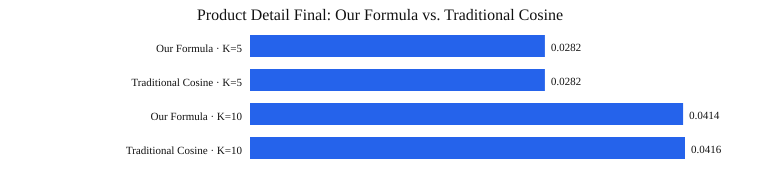

In [6]:
comparison_rows = []
for k in (5, 10):
    for name, weights in (
        ('Our Formula', BEST_WEIGHTS),
        ('Traditional Cosine', COSINE_WEIGHTS),
    ):
        comparison_rows.append({'K': k, 'method': name, **evaluate(final_similar_cases, weights, k=k)})
show_table(comparison_rows, ['K', 'method', 'cases', 'HR', 'NDCG', 'MAP', 'MRR', 'Coverage'])
bar_chart([{'label':f"{r['method']} · K={r['K']}",'NDCG':r['NDCG']} for r in comparison_rows],'label','NDCG','Product Detail Final: Our Formula vs. Traditional Cosine')

assert BEST_WEIGHTS == {'content': 0.125, 'cosine': 0.875, 'popularity': 0.0, 'business': 0.0}

## 7. Kết luận Product Detail — cập nhật 17/08/2026

Grid search trên 646 trường hợp validation chọn công thức `0.125 weightedAttribute + 0.875 cosine`. Khi khóa công thức và đánh giá trên 100 trường hợp final, mô hình đạt HR@5 = 0.05 và NDCG@5 = 0.028175, bằng cosine truyền thống; tại K=10, hai phương pháp cùng đạt HR = 0.09, còn NDCG lần lượt là 0.041380 và 0.041559.

Vì vậy, kết quả hiện tại cho thấy thành phần weighted attribute duy trì chất lượng gần tương đương cosine và bổ sung cấu trúc hybrid cho hệ thống, nhưng **chưa đủ bằng chứng để kết luận vượt cosine**. Final test là proxy next-positive-item và không tham gia chọn hệ số; kết luận chỉ áp dụng cho ngữ cảnh Product Detail trên tập dữ liệu này.